# LLM Inference Benchmarking & Optimization
### GPT-2 | PyTorch | INT8/FP16 Quantization | ROCm/CUDA Backend Detection

In [1]:
!pip install -q transformers accelerate matplotlib seaborn pandas
print('Dependencies installed.')

Dependencies installed.


## Backend Detection (CUDA / ROCm / CPU)

In [2]:
import torch
import platform

def detect_backend():
    """
    Detects the active compute backend and returns a device string.

    Returns:
        device (str): 'cuda', 'hip' (AMD), or 'cpu'
        backend_info (dict): detailed backend metadata
    """
    info = {
        'pytorch_version': torch.__version__,
        'python_version': platform.python_version(),
        'os': platform.system(),
    }

    if torch.cuda.is_available():
        device_name = torch.cuda.get_device_name(0)
        info['gpu_name'] = device_name
        info['gpu_memory_gb'] = round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2)
        info['cuda_version'] = torch.version.cuda

        hip_version = getattr(torch.version, 'hip', None)
        is_amd = (hip_version is not None) or any(
            keyword in device_name.upper()
            for keyword in ['AMD', 'RADEON', 'INSTINCT', 'VEGA', 'NAVI']
        )

        if is_amd:
            info['backend'] = 'AMD ROCm (HIP)'
            info['hip_version'] = hip_version or 'detected via device name'
            info['note'] = (
                'ROCm backend active. torch.cuda APIs are transparently mapped '
                'to HIP. GEMM ops will route to rocBLAS; attention to MIOpen or '
                'Composable Kernel (CK). Flash Attention 2 available via ROCm fork.'
            )
            device = 'cuda'
        else:
            info['backend'] = 'NVIDIA CUDA'
            info['note'] = (
                'CUDA backend active. GEMM ops route to cuBLAS; attention to cuDNN '
                'or Flash Attention. Same model code runs on AMD with ROCm PyTorch.'
            )
            device = 'cuda'
    else:
        info['backend'] = 'CPU'
        info['note'] = 'No GPU detected. Benchmarks will be slow but functionally identical.'
        device = 'cpu'

    return device, info


DEVICE, BACKEND_INFO = detect_backend()

print('=' * 60)
print('  COMPUTE BACKEND DETECTION')
print('=' * 60)
for k, v in BACKEND_INFO.items():
    print(f'  {k:<22}: {v}')
print('=' * 60)
print(f'\n Running on device: {DEVICE}')

  COMPUTE BACKEND DETECTION
  pytorch_version       : 2.10.0+cu128
  python_version        : 3.12.13
  os                    : Linux
  gpu_name              : Tesla T4
  gpu_memory_gb         : 15.64
  cuda_version          : 12.8
  backend               : NVIDIA CUDA
  note                  : CUDA backend active. GEMM ops route to cuBLAS; attention to cuDNN or Flash Attention. Same model code runs on AMD with ROCm PyTorch.

 Running on device: cuda


## Load GPT-2 Model

In [3]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import time

MODEL_NAME = 'gpt2'

print(f'Loading {MODEL_NAME}...')
tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model_fp32 = GPT2LMHeadModel.from_pretrained(MODEL_NAME)
model_fp32 = model_fp32.to(DEVICE)
model_fp32.eval()

param_count = sum(p.numel() for p in model_fp32.parameters())
print(f'Model loaded: {param_count / 1e6:.1f}M parameters')
print(f'   Precision: FP32 (baseline)')
if DEVICE == 'cuda':
    mem_used = torch.cuda.memory_allocated() / 1e6
    print(f'   VRAM used: {mem_used:.1f} MB')

Loading gpt2...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded: 124.4M parameters
   Precision: FP32 (baseline)
   VRAM used: 511.1 MB


## Benchmark Utilities

**Key metrics measured**: Latency (ms), Throughput (tkns/sec), Peak VRAM (MB)

In [4]:
import gc
import numpy as np

WARMUP_RUNS = 5
BENCHMARK_RUNS = 20
MAX_NEW_TOKENS = 50

def prepare_inputs(batch_size: int, prompt: str = 'The future of AI computing is') -> dict:
    """Tokenize and batch a prompt, move to active device."""
    inputs = tokenizer(
        [prompt] * batch_size,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=32
    )
    return {k: v.to(DEVICE) for k, v in inputs.items()}


def benchmark_model(model, batch_size: int, label: str = '') -> dict:
    """
    Benchmark inference latency, throughput, and peak VRAM for a given model and batch size.

    Args:
        model: PyTorch model in eval mode
        batch_size: number of sequences per forward pass
        label: human-readable label for logging

    Returns:
        dict with latency_ms, throughput_tps, peak_vram_mb
    """
    inputs = prepare_inputs(batch_size)
    input_len = inputs['input_ids'].shape[1]
    total_tokens = batch_size * (input_len + MAX_NEW_TOKENS)

    if DEVICE == 'cuda':
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    latencies = []

    with torch.no_grad():
        for _ in range(WARMUP_RUNS):
            _ = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        if DEVICE == 'cuda':
            torch.cuda.synchronize()

        for i in range(BENCHMARK_RUNS):
            if DEVICE == 'cuda':
                torch.cuda.synchronize()
            t0 = time.perf_counter()

            _ = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

            if DEVICE == 'cuda':
                torch.cuda.synchronize()
            t1 = time.perf_counter()
            latencies.append((t1 - t0) * 1000)

    mean_latency = np.mean(latencies)
    std_latency = np.std(latencies)
    throughput = (total_tokens / (mean_latency / 1000))
    peak_vram = (
        torch.cuda.max_memory_allocated() / 1e6
        if DEVICE == 'cuda' else 0.0
    )

    result = {
        'label': label,
        'batch_size': batch_size,
        'latency_ms': round(mean_latency, 2),
        'latency_std_ms': round(std_latency, 2),
        'throughput_tps': round(throughput, 1),
        'peak_vram_mb': round(peak_vram, 1),
    }

    print(f'  [{label}] bs={batch_size:2d} | '
          f'latency={mean_latency:.1f}±{std_latency:.1f}ms | '
          f'throughput={throughput:.0f} tok/s | '
          f'VRAM={peak_vram:.0f}MB')

    return result

print('Benchmark utilities ready.')

Benchmark utilities ready.


## Cell 5 — Run FP32 Baseline Benchmarks

In [5]:
BATCH_SIZES = [1, 2, 4, 8]

print('Running FP32 baseline benchmarks...')
print('-' * 70)

fp32_results = []
for bs in BATCH_SIZES:
    result = benchmark_model(model_fp32, batch_size=bs, label='FP32')
    fp32_results.append(result)

print('-' * 70)
print('FP32 baseline complete.')

Running FP32 baseline benchmarks...
----------------------------------------------------------------------
  [FP32] bs= 1 | latency=525.9±34.2ms | throughput=106 tok/s | VRAM=526MB
  [FP32] bs= 2 | latency=499.9±54.5ms | throughput=224 tok/s | VRAM=531MB
  [FP32] bs= 4 | latency=540.3±66.6ms | throughput=415 tok/s | VRAM=540MB
  [FP32] bs= 8 | latency=551.3±66.0ms | throughput=813 tok/s | VRAM=572MB
----------------------------------------------------------------------
FP32 baseline complete.


## FP16 Optimization


In [6]:
print('Loading FP16 model...')

model_fp16 = GPT2LMHeadModel.from_pretrained(MODEL_NAME)
model_fp16 = model_fp16.half()
model_fp16 = model_fp16.to(DEVICE)
model_fp16.eval()

if DEVICE == 'cuda':
    mem_used = torch.cuda.memory_allocated() / 1e6
    print(f'FP16 model loaded — VRAM: {mem_used:.1f} MB')
    print(f'   (compare to FP32: {fp32_results[0]["peak_vram_mb"]} MB at bs=1)')
else:
    print('FP16 model loaded (CPU mode — FP16 inference may be slow on CPU)')

print('\nRunning FP16 benchmarks...')
print('-' * 70)

fp16_results = []
for bs in BATCH_SIZES:
    result = benchmark_model(model_fp16, batch_size=bs, label='FP16')
    fp16_results.append(result)

print('-' * 70)
print('FP16 benchmarks complete.')

del model_fp32
gc.collect()
if DEVICE == 'cuda':
    torch.cuda.empty_cache()

Loading FP16 model...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FP16 model loaded — VRAM: 796.7 MB
   (compare to FP32: 526.0 MB at bs=1)

Running FP16 benchmarks...
----------------------------------------------------------------------
  [FP16] bs= 1 | latency=547.5±59.3ms | throughput=102 tok/s | VRAM=799MB
  [FP16] bs= 2 | latency=769.4±461.7ms | throughput=146 tok/s | VRAM=802MB
  [FP16] bs= 4 | latency=519.5±47.3ms | throughput=431 tok/s | VRAM=807MB
  [FP16] bs= 8 | latency=520.2±68.1ms | throughput=861 tok/s | VRAM=818MB
----------------------------------------------------------------------
FP16 benchmarks complete.


## INT8 Dynamic Quantization


In [7]:
print('Applying INT8 dynamic quantization...')
print('(INT8 dynamic quant runs on CPU — CUDA backend limitations)')
print('On AMD ROCm production: use AMD Quark or torch-ort for GPU-native INT8.')
print()

model_int8_base = GPT2LMHeadModel.from_pretrained(MODEL_NAME)
model_int8_base.eval()

model_int8 = torch.quantization.quantize_dynamic(
    model_int8_base,
    {torch.nn.Linear},
    dtype=torch.qint8
)

import os, tempfile

def get_model_size_mb(model):
    with tempfile.NamedTemporaryFile(delete=False, suffix='.pt') as f:
        torch.save(model.state_dict(), f.name)
        size_mb = os.path.getsize(f.name) / 1e6
    os.unlink(f.name)
    return round(size_mb, 1)

model_fp16_size = get_model_size_mb(model_fp16)
model_int8_size = get_model_size_mb(model_int8)

print(f'INT8 quantization applied.')
print(f'   FP16 model size : {model_fp16_size} MB')
print(f'   INT8 model size : {model_int8_size} MB')
print(f'   Compression     : {model_fp16_size / model_int8_size:.1f}x smaller')

print('\nRunning INT8 benchmarks (CPU)...')
print('-' * 70)

INT8_BATCH_SIZES = [1, 2, 4]

int8_results = []
_device_backup = DEVICE
DEVICE_INT8 = 'cpu'

inputs_cpu = {k: v.cpu() for k, v in prepare_inputs(1).items()}

import time as _time

for bs in INT8_BATCH_SIZES:
    inputs = tokenizer(
        ['The future of AI computing is'] * bs,
        return_tensors='pt', padding=True, truncation=True, max_length=32
    )
    with torch.no_grad():
        for _ in range(2):
            model_int8.generate(**inputs, max_new_tokens=20, do_sample=False,
                                pad_token_id=tokenizer.eos_token_id)
    latencies_i8 = []
    with torch.no_grad():
        for _ in range(5):
            t0 = _time.perf_counter()
            model_int8.generate(**inputs, max_new_tokens=20, do_sample=False,
                                pad_token_id=tokenizer.eos_token_id)
            t1 = _time.perf_counter()
            latencies_i8.append((t1 - t0) * 1000)

    total_tokens = bs * (inputs['input_ids'].shape[1] + 20)
    mean_lat = np.mean(latencies_i8)
    tps = total_tokens / (mean_lat / 1000)

    result = {
        'label': 'INT8 (CPU)',
        'batch_size': bs,
        'latency_ms': round(mean_lat, 2),
        'latency_std_ms': round(np.std(latencies_i8), 2),
        'throughput_tps': round(tps, 1),
        'peak_vram_mb': 0.0,
    }
    int8_results.append(result)
    print(f'  [INT8] bs={bs:2d} | latency={mean_lat:.1f}ms | throughput={tps:.0f} tok/s | VRAM=N/A (CPU)')

print('-' * 70)
print('INT8 benchmarks complete.')

Applying INT8 dynamic quantization...
(INT8 dynamic quant runs on CPU — CUDA backend limitations)
On AMD ROCm production: use AMD Quark or torch-ort for GPU-native INT8.



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_7920/3147891891.py:9: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_int8

INT8 quantization applied.
   FP16 model size : 248.9 MB
   INT8 model size : 536.4 MB
   Compression     : 0.5x smaller

Running INT8 benchmarks (CPU)...
----------------------------------------------------------------------
  [INT8] bs= 1 | latency=846.7ms | throughput=31 tok/s | VRAM=N/A (CPU)
  [INT8] bs= 2 | latency=1283.1ms | throughput=41 tok/s | VRAM=N/A (CPU)
  [INT8] bs= 4 | latency=1302.4ms | throughput=80 tok/s | VRAM=N/A (CPU)
----------------------------------------------------------------------
INT8 benchmarks complete.


## Compile Results Table

In [8]:
import pandas as pd

all_results = fp32_results + fp16_results + int8_results
df = pd.DataFrame(all_results)

print('=' * 70)
print('  BENCHMARK RESULTS SUMMARY')
print('=' * 70)
print(df[['label', 'batch_size', 'latency_ms', 'throughput_tps', 'peak_vram_mb']].to_string(index=False))
print('=' * 70)

fp32_bs1_lat = df[(df.label == 'FP32') & (df.batch_size == 1)]['latency_ms'].values[0]
fp16_bs1_lat = df[(df.label == 'FP16') & (df.batch_size == 1)]['latency_ms'].values[0]
fp32_bs1_mem = df[(df.label == 'FP32') & (df.batch_size == 1)]['peak_vram_mb'].values[0]
fp16_bs1_mem = df[(df.label == 'FP16') & (df.batch_size == 1)]['peak_vram_mb'].values[0]

print(f'\nFP16 speedup over FP32 (bs=1): {fp32_bs1_lat / fp16_bs1_lat:.2f}x faster')
if fp16_bs1_mem > 0 and fp32_bs1_mem > 0:
    print(f'FP16 memory reduction (bs=1):  {fp32_bs1_mem / fp16_bs1_mem:.2f}x less VRAM')

  BENCHMARK RESULTS SUMMARY
     label  batch_size  latency_ms  throughput_tps  peak_vram_mb
      FP32           1      525.92           106.5         526.0
      FP32           2      499.91           224.0         530.7
      FP32           4      540.32           414.6         540.0
      FP32           8      551.32           812.6         572.2
      FP16           1      547.46           102.3         799.3
      FP16           2      769.36           145.6         801.8
      FP16           4      519.50           431.2         806.9
      FP16           8      520.19           861.2         818.0
INT8 (CPU)           1      846.74            30.7           0.0
INT8 (CPU)           2     1283.11            40.5           0.0
INT8 (CPU)           4     1302.39            79.9           0.0

FP16 speedup over FP32 (bs=1): 0.96x faster
FP16 memory reduction (bs=1):  0.66x less VRAM


## Visualize Results

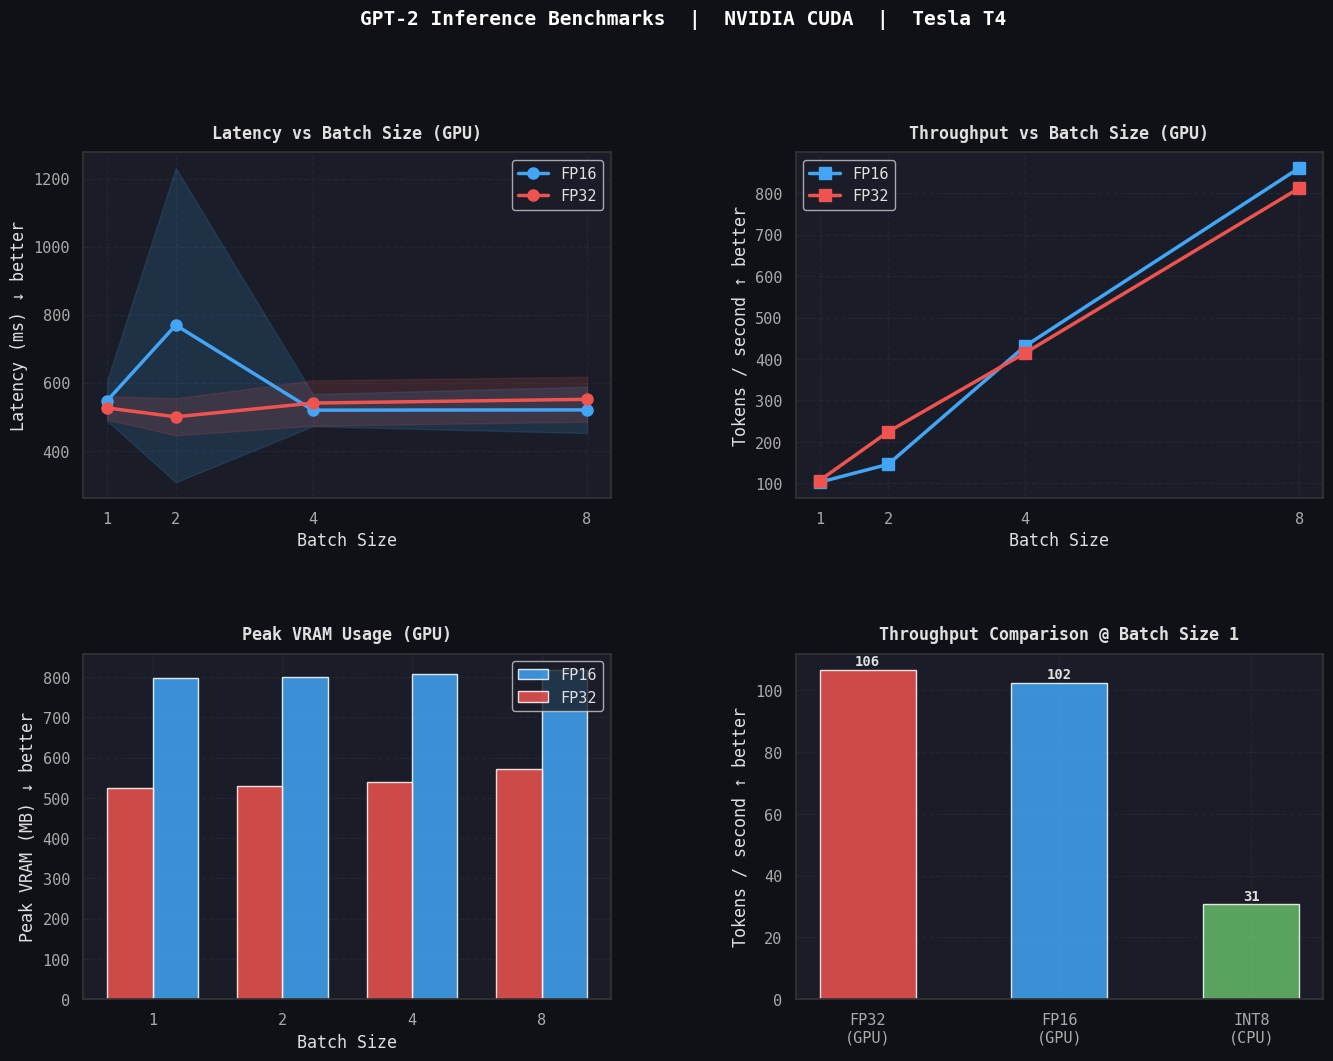

Plot saved as benchmark_results.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#333',
    'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#aaa',
    'ytick.color': '#aaa',
    'text.color': '#e0e0e0',
    'grid.color': '#2a2d3a',
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
    'font.family': 'monospace',
})

COLORS = {
    'FP32':       '#ef5350',  # red
    'FP16':       '#42a5f5',  # blue
    'INT8 (CPU)': '#66bb6a',  # green
}

fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('#0f1117')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# Plot 1: Latency vs Batch Size
ax1 = fig.add_subplot(gs[0, 0])
for label, group in df[df.label != 'INT8 (CPU)'].groupby('label'):
    ax1.plot(group['batch_size'], group['latency_ms'],
             marker='o', linewidth=2.5, markersize=8,
             color=COLORS[label], label=label)
    ax1.fill_between(
        group['batch_size'],
        group['latency_ms'] - group['latency_std_ms'],
        group['latency_ms'] + group['latency_std_ms'],
        alpha=0.15, color=COLORS[label]
    )
ax1.set_title('Latency vs Batch Size (GPU)', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Latency (ms) ↓ better')
ax1.legend()
ax1.set_xticks(BATCH_SIZES)

# Plot 2: Throughput vs Batch Size
ax2 = fig.add_subplot(gs[0, 1])
for label, group in df[df.label != 'INT8 (CPU)'].groupby('label'):
    ax2.plot(group['batch_size'], group['throughput_tps'],
             marker='s', linewidth=2.5, markersize=8,
             color=COLORS[label], label=label)
ax2.set_title('Throughput vs Batch Size (GPU)', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Batch Size')
ax2.set_ylabel('Tokens / second ↑ better')
ax2.legend()
ax2.set_xticks(BATCH_SIZES)

# Plot 3: Peak VRAM
ax3 = fig.add_subplot(gs[1, 0])
for label, group in df[df.label != 'INT8 (CPU)'].groupby('label'):
    ax3.bar(
        [x + (0 if label == 'FP32' else 0.35) for x in range(len(BATCH_SIZES))],
        group['peak_vram_mb'],
        width=0.35, label=label, color=COLORS[label], alpha=0.85
    )
ax3.set_title('Peak VRAM Usage (GPU)', fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel('Batch Size')
ax3.set_ylabel('Peak VRAM (MB) ↓ better')
ax3.set_xticks([x + 0.175 for x in range(len(BATCH_SIZES))], BATCH_SIZES)
ax3.legend()

#  Plot 4: FP16 speedup + INT8 at bs=1
ax4 = fig.add_subplot(gs[1, 1])

categories = ['FP32\n(GPU)', 'FP16\n(GPU)', 'INT8\n(CPU)']
tps_values = [
    df[(df.label == 'FP32') & (df.batch_size == 1)]['throughput_tps'].values[0],
    df[(df.label == 'FP16') & (df.batch_size == 1)]['throughput_tps'].values[0],
    df[(df.label == 'INT8 (CPU)') & (df.batch_size == 1)]['throughput_tps'].values[0],
]
bar_colors = [COLORS['FP32'], COLORS['FP16'], COLORS['INT8 (CPU)']]

bars = ax4.bar(categories, tps_values, color=bar_colors, alpha=0.85, width=0.5)
for bar, val in zip(bars, tps_values):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax4.set_title('Throughput Comparison @ Batch Size 1', fontsize=12, fontweight='bold', pad=10)
ax4.set_ylabel('Tokens / second ↑ better')

# Title
fig.suptitle(
    f'GPT-2 Inference Benchmarks  |  {BACKEND_INFO["backend"]}  |  '
    f'{BACKEND_INFO.get("gpu_name", "CPU")}',
    fontsize=14, fontweight='bold', color='#ffffff', y=1.01
)

plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Plot saved as benchmark_results.png')

## Operator-Level Profiling (GEMM / Attention)

In [10]:
from torch.profiler import profile, record_function, ProfilerActivity

inputs = prepare_inputs(batch_size=1)

activities = [ProfilerActivity.CPU]
if DEVICE == 'cuda':
    activities.append(ProfilerActivity.CUDA)

print('Profiling a single FP16 forward pass (greedy decode, 20 tokens)...')
print('This reveals which operators dominate — GEMM, Attention, etc.\n')

with profile(
    activities=activities,
    record_shapes=True,
    with_flops=True,
    profile_memory=True,
) as prof:
    with record_function('gpt2_inference'):
        with torch.no_grad():
            model_fp16.generate(
                **inputs,
                max_new_tokens=20,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

# Top 15 ops by GPU time
sort_key = 'cuda_time_total' if DEVICE == 'cuda' else 'cpu_time_total'
print(prof.key_averages().table(
    sort_by=sort_key,
    row_limit=15
))

print()
print('Key operators to note:')
print('  aten::mm / aten::addmm  → GEMM (matrix multiply) — CUDA: cuBLAS | ROCm: rocBLAS/CK')
print('  aten::scaled_dot_product_attention → Attention — CUDA: FlashAttention | ROCm: CK or MIOpen')
print('  aten::layer_norm        → LayerNorm — fused on both backends')
print('  aten::gelu              → GELU activation — elementwise, typically not a bottleneck')

Profiling a single FP16 forward pass (greedy decode, 20 tokens)...
This reveals which operators dominate — GEMM, Attention, etc.



/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  Total MFLOPs  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                         gpt2_inference         0.00%       0.000us         0.00%       0.000us       0.000us     408.447ms       644.79%     408.447ms     408.447ms           0 

## Becnhmark Summary

In [11]:
print('=' * 70)
print('  BENCHMARK SUMMARY')
print('=' * 70)

fp32_tps_max = df[df.label == 'FP32']['throughput_tps'].max()
fp16_tps_max = df[df.label == 'FP16']['throughput_tps'].max()
fp32_tps_bs1 = df[(df.label == 'FP32') & (df.batch_size == 1)]['throughput_tps'].values[0]
fp16_tps_bs1 = df[(df.label == 'FP16') & (df.batch_size == 1)]['throughput_tps'].values[0]

print(f'\nModel        : GPT-2 ({param_count/1e6:.0f}M params)')
print(f'Backend      : {BACKEND_INFO["backend"]}')
print(f'GPU          : {BACKEND_INFO.get("gpu_name", "N/A")}')
print()
print(f'FP32 max throughput : {fp32_tps_max:.0f} tok/s')
print(f'FP16 max throughput : {fp16_tps_max:.0f} tok/s  ({fp16_tps_max/fp32_tps_max:.2f}x speedup)')
print(f'FP16 speedup @ bs=1 : {fp16_tps_bs1/fp32_tps_bs1:.2f}x')

  BENCHMARK SUMMARY

Model        : GPT-2 (124M params)
Backend      : NVIDIA CUDA
GPU          : Tesla T4

FP32 max throughput : 813 tok/s
FP16 max throughput : 861 tok/s  (1.06x speedup)
FP16 speedup @ bs=1 : 0.96x
